In [5]:
from google.colab import files
uploaded = files.upload()

Saving balanced_fault_dataset-1.csv to balanced_fault_dataset-1.csv


Training Random Forest Regressor...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa


[Model Metrics]
Mean Squared Error: 0.000063
R-Squared: 0.9994


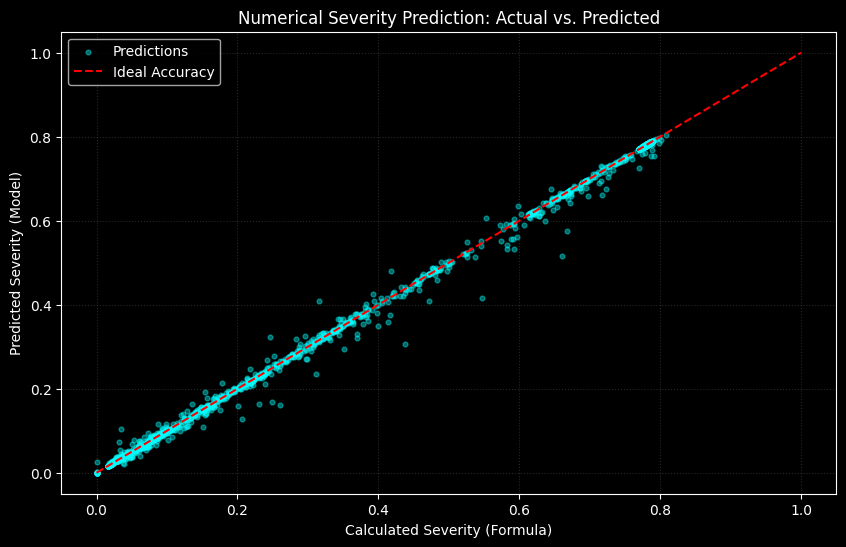

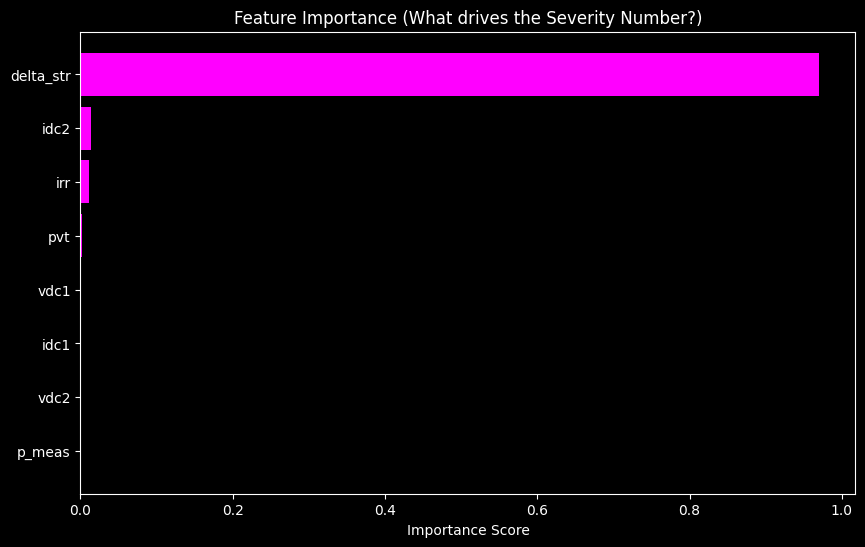

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Load the balanced fault dataset
df = pd.read_csv('balanced_fault_dataset-1.csv')

# 2. Define Features and Target
# Using raw sensor data + engineered mismatch and power features
features = ['vdc1', 'vdc2', 'idc1', 'idc2', 'irr', 'pvt', 'p_meas', 'delta_str']
X = df[features]
y = df['severity_index']

# 3. Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Model
# We use 100 trees to ensure a stable confidence calculation
print("Training Random Forest Regressor...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

# 5. Prediction and Numerical Confidence Scoring
y_pred = model.predict(X_test)

# Calculate Confidence Score (%)
# Based on the standard deviation (disagreement) between individual trees
tree_predictions = np.array([tree.predict(X_test) for tree in model.estimators_])
std_dev = np.std(tree_predictions, axis=0)
confidence = np.clip(100 * (1 - (std_dev / (std_dev.max() + 1e-6))), 0, 100)

# 6. Evaluation Metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"\n[Model Metrics]\nMean Squared Error: {mse:.6f}\nR-Squared: {r2:.4f}")

# 7. Visualization (Dark Theme)
# I've applied the dark background style as you previously requested
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.4, color='cyan', s=12, label='Predictions')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Ideal Accuracy')

plt.title('Numerical Severity Prediction: Actual vs. Predicted')
plt.xlabel('Calculated Severity (Formula)')
plt.ylabel('Predicted Severity (Model)')
plt.legend()
plt.grid(color='gray', linestyle=':', alpha=0.3)
plt.show()

# 8. Feature Importance (Diagnostic)
importances = model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importance (What drives the Severity Number?)')
plt.barh(range(len(indices)), importances[indices], color='magenta', align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Importance Score')
plt.show()

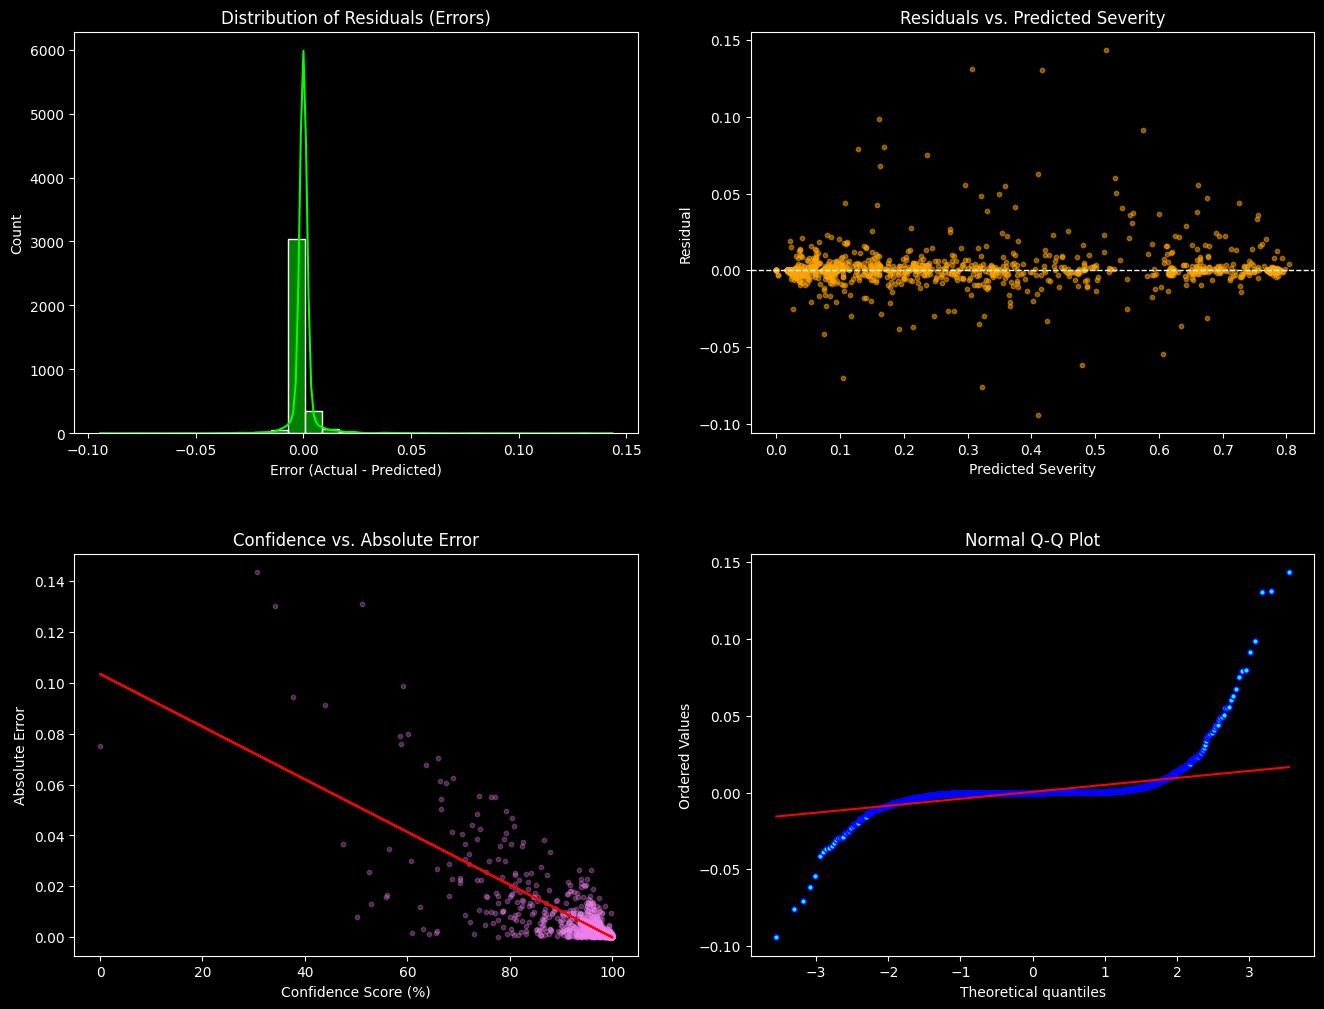

--- Detailed Diagnostic Summary ---
Mean Absolute Error (MAE): 0.002094
Max Error: 0.143505
Median Absolute Error: 0.000255
Confidence/Error Correlation: -0.7942


In [8]:
import seaborn as sns
from scipy import stats

# 1. Calculate Residuals
residuals = y_test - y_pred

# 2. Setup Comprehensive Evaluation Plot (Dark Theme)
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
plt.subplots_adjust(hspace=0.3, wspace=0.2)

# --- Plot A: Residual Distribution ---
# Checks if errors are normally distributed (ideal)
sns.histplot(residuals, kde=True, ax=axes[0, 0], color='lime', bins=30)
axes[0, 0].set_title('Distribution of Residuals (Errors)')
axes[0, 0].set_xlabel('Error (Actual - Predicted)')

# --- Plot B: Residuals vs. Predicted (Heteroscedasticity) ---
# Checks if the model gets "noisier" at high or low severity
axes[0, 1].scatter(y_pred, residuals, alpha=0.5, color='orange', s=10)
axes[0, 1].axhline(0, color='white', linestyle='--', linewidth=1)
axes[0, 1].set_title('Residuals vs. Predicted Severity')
axes[0, 1].set_xlabel('Predicted Severity')
axes[0, 1].set_ylabel('Residual')

# --- Plot C: Confidence vs. Absolute Error ---
# Checks if your calculated 'confidence' actually correlates with lower error
abs_error = np.abs(residuals)
axes[1, 0].scatter(confidence, abs_error, alpha=0.3, color='violet', s=10)
axes[1, 0].set_title('Confidence vs. Absolute Error')
axes[1, 0].set_xlabel('Confidence Score (%)')
axes[1, 0].set_ylabel('Absolute Error')
# Trend line to see if higher confidence = lower error
m, b = np.polyfit(confidence, abs_error, 1)
axes[1, 0].plot(confidence, m*confidence + b, color='red', label='Error Trend')

# --- Plot D: Probability Plot (Q-Q Plot) ---
# Checks for outliers and systematic bias
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_markerfacecolor('cyan')
axes[1, 1].get_lines()[0].set_markersize(4)
axes[1, 1].set_title('Normal Q-Q Plot')

plt.show()

# 3. Supplemental Metrics Breakdown
print(f"--- Detailed Diagnostic Summary ---")
print(f"Mean Absolute Error (MAE): {np.mean(abs_error):.6f}")
print(f"Max Error: {np.max(abs_error):.6f}")
print(f"Median Absolute Error: {np.median(abs_error):.6f}")
print(f"Confidence/Error Correlation: {np.corrcoef(confidence, abs_error)[0,1]:.4f}")

In [ ]:
# Function to test the RFR model with 3 different scenarios
def test_rfr_model(vdc1, vdc2, idc1, idc2, irr, pvt):
    # 1. Feature Engineering (Same logic as XGBoost for consistency)
    p_meas = (vdc1 * idc1) + (vdc2 * idc2)
    delta_str = abs((vdc1 * idc1) - (vdc2 * idc2)) / (p_meas + 1e-6)

    # Arrange features in a 2D array
    input_array = np.array([[vdc1, vdc2, idc1, idc2, irr, pvt, p_meas, delta_str]])

    # Convert to DataFrame with feature names to match training data
    # The 'features' list is available from the training cell (vuYucwIp4Jif)
    input_data_df = pd.DataFrame(input_array, columns=['vdc1', 'vdc2', 'idc1', 'idc2', 'irr', 'pvt', 'p_meas', 'delta_str'])

    # 2. Get Numerical Prediction (Mean of all trees)
    severity_pred = model.predict(input_data_df)[0]

    # 3. Get Confidence Score (Variance-based)
    # RFR makes this easy: we just look at every tree's individual opinion
    tree_opinions = np.array([tree.predict(input_data_df) for tree in model.estimators_])
    std_dev = np.std(tree_opinions)

    # Normalize: if std_dev is 0, confidence is 100%.
    # If it's high (e.g., 0.1), confidence drops.
    conf_score = np.clip(100 * (1 - (std_dev / 0.1)), 0, 100)

    return severity_pred, conf_score

# --- TEST CASES ---
# Scenario 1: Healthy/Minor Soiling
s1, c1 = test_rfr_model(260, 200, 9.2, 9.0, 990, 43)

# Scenario 2: Open Circuit / String Fault
s2, c2 = test_rfr_model(260, 50, 9.2, 0.1, 990, 45)

# Scenario 3: Potential Hardware Degradation
s3, c3 = test_rfr_model(280, 280, 2.5, 2.1, 900, 32)

print("--- RFR MODEL TEST RESULTS ---")
print(f"Scenario 1: Severity {s1:.3f} | Confidence {c1:.1f}%")
print(f"Scenario 2: Severity {s2:.3f} | Confidence {c2:.1f}%")
print(f"Scenario 3: Severity {s3:.3f} | Confidence {c3:.1f}%")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa

--- RFR MODEL TEST RESULTS ---
Scenario 1: Severity 0.094 | Confidence 94.0%
Scenario 2: Severity 0.784 | Confidence 96.7%
Scenario 3: Severity 0.251 | Confidence 25.3%


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWa